# **Evaluacion Modelo Predicción de 5 semanas del precio de banano**

## Inicialización y carga de datos

In [2]:
# ============================================
# Forecast 5 semanas con 5 lags
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import warnings
warnings.filterwarnings("ignore")

# Para Colab (comentarlo si no usas Colab)
try:
    from google.colab import files
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    uploaded = files.upload()  # Sube 'precio_ecuador.xlsx'

# -----------------------------
# 1) Cargar datos
# -----------------------------
FILENAME = 'precio_ecuador.xlsx'  # cambia si el nombre difiere
df = pd.read_excel(FILENAME)

# -----------------------------
# 2) Crear Fecha (ISO Week) y ordenar
# -----------------------------
# Se asume columnas: Año, Semana, Precio
df['Fecha'] = pd.to_datetime(
    df['Año'].astype(str) + df['Semana'].astype(str) + '1',
    format='%G%V%u'
)
df = df.sort_values('Fecha').reset_index(drop=True)

# -----------------------------
# 3) Crear 5 lags
# -----------------------------
for i in range(1, 6):
    df[f"Precio_t-{i}"] = df["Precio"].shift(i)
df = df.dropna().reset_index(drop=True)

# -----------------------------
# 4) Features/Target y Escalado de X
# -----------------------------
from sklearn.preprocessing import MinMaxScaler

features = [c for c in df.columns if c.startswith("Precio_t-")]
target = "Precio"

scaler_X = MinMaxScaler()
X_all = scaler_X.fit_transform(df[features].values)
y_all = df[target].values  # sin escalar para MAPE correcto

# -----------------------------
# 5) Confirmar/forzar última semana disponible
# -----------------------------
last_row = df.iloc[-1]
last_year_default = int(last_row['Año'])
last_week_default = int(last_row['Semana'])

print(f"Último registro detectado en datos: Año={last_year_default}, Semana={last_week_default}, Fecha={last_row['Fecha'].date()}")

try:
    inp = input(f"Ingrese la última semana disponible (ENTER para {last_week_default}): ").strip()
    last_week_user = int(inp) if inp else last_week_default
except:
    last_week_user = last_week_default

# Si te interesa forzar también el año (opcional):
try:
    inp_y = input(f"Ingrese el año de la última semana (ENTER para {last_year_default}): ").strip()
    last_year_user = int(inp_y) if inp_y else last_year_default
except:
    last_year_user = last_year_default

# Validación ligera: si difiere, solo informamos (el forecast se ancla a la última fila real)
if (last_year_user != last_year_default) or (last_week_user != last_week_default):
    print("Nota: Los datos reales llegan hasta "
          f"Año={last_year_default}, Semana={last_week_default}. "
          "El forecast se construirá a partir del último registro real, "
          "pero se etiquetará con las semanas futuras correctas.")

Último registro detectado en datos: Año=2025, Semana=27, Fecha=2025-06-30
Ingrese la última semana disponible (ENTER para 27): 
Ingrese el año de la última semana (ENTER para 2025): 


# Preparación de modelos

In [3]:
# -----------------------------
# 6) Partición temporal (para SuperLearner OOF)
#    y luego entrenamiento final con todo el histórico
# -----------------------------
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

def MAPE(y_true, y_pred, eps=1e-8):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

def report_model(y_true, y_pred, tag):
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = MAPE(y_true, y_pred)
    print(f"{tag} -> RMSE: {rmse:.3f} | MAE: {mae:.3f} | MAPE: {mape:.2f}%")
    return rmse, mae, mape

tscv = TimeSeriesSplit(n_splits=5)

# -----------------------------
# 7) Definición de modelos con hiperparámetros óptimos (modelo 2)
# -----------------------------
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_models():
    ridge = Ridge(alpha=1e-05)

    mlp = MLPRegressor(
        hidden_layer_sizes=(64, 64),
        activation='tanh',
        alpha=1e-06,
        learning_rate_init=0.003,
        max_iter=2000,
        random_state=42
    )

    xgb = XGBRegressor(
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=1.0,
        gamma=0.1,
        n_estimators=300,
        reg_alpha=0.001,
        reg_lambda=1,
        objective='reg:squarederror',
        tree_method='gpu_hist' if tf.config.list_physical_devices('GPU') else 'hist',
        random_state=42
    )

    # LSTM: entrada como secuencia de longitud = n_features (5 lags)
    def make_lstm():
        model = Sequential([
            Input(shape=(X_all.shape[1], 1)), # (timesteps=5, features=1)
            LSTM(96, return_sequences=False),
            Dropout(0.3),
            Dense(1)
        ])
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss='mse')
        return model

    return ridge, mlp, xgb, make_lstm

ridge, mlp, xgb, make_lstm = build_models()

# Entrenamiento y predicción

In [4]:
# -----------------------------
# 8) OOF para meta-modelo (SuperLearner)
# -----------------------------
def to_seq(X):  # (n_samples, n_features) -> (n_samples, timesteps=n_features, 1)
    return X.reshape((X.shape[0], X.shape[1], 1))

oof_preds = []
oof_y = []

for tr_idx, va_idx in tscv.split(X_all):
    X_tr, X_va = X_all[tr_idx], X_all[va_idx]
    y_tr, y_va = y_all[tr_idx], y_all[va_idx]

    # Re-crear modelos por fold (evitar "leaks")
    ridge_f, mlp_f, xgb_f, make_lstm_f = build_models()

    # Fit modelos clásicos
    ridge_f.fit(X_tr, y_tr)
    mlp_f.fit(X_tr, y_tr)
    xgb_f.fit(X_tr, y_tr)

    # LSTM
    lstm_f = make_lstm_f()
    cb = [
        EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(factor=0.5, patience=7, verbose=0)
    ]
    lstm_f.fit(to_seq(X_tr), y_tr,
               validation_data=(to_seq(X_va), y_va),
               epochs=100, batch_size=16, verbose=0, callbacks=cb)

    # Predicciones OOF (en el fold de validación)
    preds_fold = np.vstack([
        ridge_f.predict(X_va),
        mlp_f.predict(X_va),
        xgb_f.predict(X_va),
        lstm_f.predict(to_seq(X_va)).ravel()
    ]).T

    oof_preds.append(preds_fold)
    oof_y.append(y_va)

meta_X = np.vstack(oof_preds)
meta_y = np.concatenate(oof_y)

# Meta-modelo (Ridge pequeño)
from sklearn.linear_model import RidgeCV
meta_model = RidgeCV(alphas=np.logspace(-4, 2, 20), cv=tscv)
meta_model.fit(meta_X, meta_y)

# -----------------------------
# 9) Re-entrenar modelos base con TODO el histórico
# -----------------------------
ridge.fit(X_all, y_all)
mlp.fit(X_all, y_all)
xgb.fit(X_all, y_all)

lstm = make_lstm()
cb_final = [
    EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=7, verbose=0)
]
lstm.fit(to_seq(X_all), y_all, validation_split=0.15,
         epochs=100, batch_size=16, verbose=0, callbacks=cb_final)

# -----------------------------
# 10) Forecast iterativo 5 pasos (actualiza lags con cada predicción)
# -----------------------------
def forecast_k_steps(models, last_prices, k=5):
    """
    models: dict con funciones de predicción:
        {
          "Ridge": lambda X: ridge.predict(X),
          "MLP":   lambda X: mlp.predict(X),
          "XGB":   lambda X: xgb.predict(X),
          "LSTM":  lambda X_seq: lstm.predict(X_seq).ravel()
        }
    last_prices: lista/array con las últimas 5 observaciones reales (más reciente al final)
    k: número de pasos a pronosticar
    """
    # Estado de lags se actualiza por modelo de forma independiente
    out = {m: [] for m in models.keys()}

    for model_name in models.keys():
        # Copia el “estado” de lags para este modelo
        state = list(last_prices)  # [y_{t-4}, ..., y_{t}]
        preds = []
        for _ in range(k):
            # Construir vector de lags: Precio_t-1 ... Precio_t-5 (como en training)
            lags = np.array(state[-5:][::-1])  # orden: t-1, t-2, ..., t-5
            # Escalar como features
            X_feat = scaler_X.transform(lags.reshape(1, -1))

            if model_name == "LSTM":
                y_hat = models[model_name](to_seq(X_feat))[0]
            else:
                y_hat = models[model_name](X_feat)[0]

            preds.append(float(y_hat))
            # Actualiza estado con el nuevo pronóstico
            state.append(float(y_hat))
        out[model_name] = preds

    return out

# Tomamos las últimas 5 observaciones reales para iniciar los lags
last_5_prices = df['Precio'].values[-5:]

models_predictors = {
    "Ridge": lambda X: ridge.predict(X),
    "MLP":   lambda X: mlp.predict(X),
    "XGB":   lambda X: xgb.predict(X),
    "LSTM":  lambda X_seq: lstm.predict(X_seq).ravel()
}

base_forecasts = forecast_k_steps(models_predictors, last_5_prices, k=5)

# SuperLearner: combina predicciones de base en cada horizonte
def super_forecast_from_bases(base_forecasts):
    # base_forecasts: dict modelo -> [h1..h5]
    horizons = len(next(iter(base_forecasts.values())))
    sup = []
    for h in range(horizons):
        # Para cada horizonte construimos el vector meta_X = [ridge, mlp, xgb, lstm]
        meta_x_h = np.array([
            base_forecasts["Ridge"][h],
            base_forecasts["MLP"][h],
            base_forecasts["XGB"][h],
            base_forecasts["LSTM"][h]
        ]).reshape(1, -1)
        y_hat = meta_model.predict(meta_x_h)[0]
        sup.append(float(y_hat))
    return sup

sup_preds = super_forecast_from_bases(base_forecasts)
base_forecasts["SuperLearner"] = sup_preds

# -----------------------------
# 11) Construir etiquetas de semanas futuras (Año, Semana, Fecha)
# -----------------------------
# A partir de la última Fecha real
last_date = df['Fecha'].iloc[-1]
future_dates = [last_date + pd.Timedelta(days=7 * i) for i in range(1, 6)]

future_years = [int(d.isocalendar().year) for d in future_dates]
future_weeks = [int(d.isocalendar().week) for d in future_dates]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


# Generación de tabla y gráficos


📊 Pronóstico de las siguientes 5 semanas año 2025 por modelo:


Semana,Ridge,MLP,XGB,LSTM,SuperLearner
28,10.67,10.35,10.38,10.06,10.62
29,10.02,9.78,9.34,9.88,10.00
30,9.70,9.56,9.08,9.69,9.70
31,9.44,9.48,9.40,9.54,9.49
32,9.13,9.32,8.23,9.43,9.14


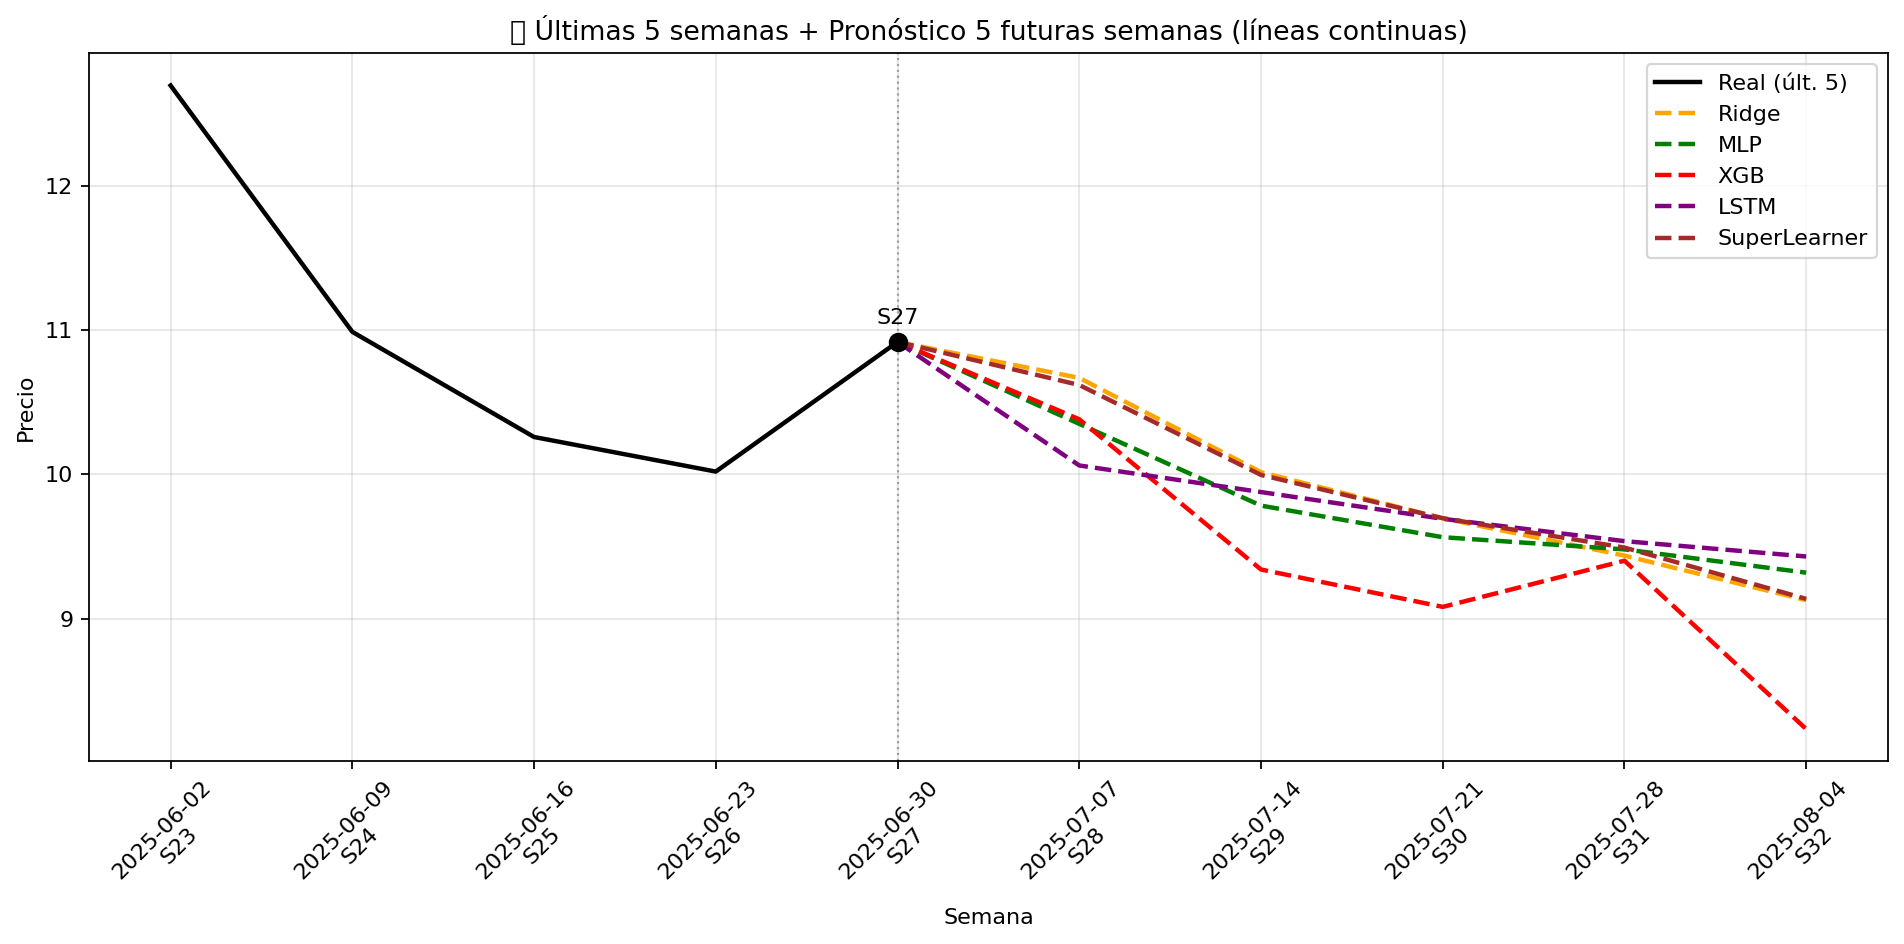

In [5]:
# -----------------------------
# 12) Tabla limpia: semanas como filas, modelos como columnas
# -----------------------------
# Creamos el DataFrame sin 'Año' ni 'Fecha'
tabla_forecast = pd.DataFrame({
    "Semana": future_weeks
})

# Agregamos las predicciones por modelo
for model_name, preds in base_forecasts.items():
    tabla_forecast[model_name] = preds

# Convertimos la semana a entero
tabla_forecast["Semana"] = tabla_forecast["Semana"].astype(int)

# Mostramos la tabla limpia y formateada
print("\n📊 Pronóstico de las siguientes 5 semanas año 2025 por modelo:")
display(
    tabla_forecast.style
    .format("{:.2f}", subset=["Ridge", "MLP", "XGB", "LSTM", "SuperLearner"])
    .hide(axis="index")  # oculta el índice 0,1,2,3...
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#f4f4f4"), ("font-weight", "bold"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center")]}
    ])
)

# -----------------------------
# 13) Gráfico continuo: últimas 5 reales + pronósticos (5 modelos)
# -----------------------------
fig, ax = plt.subplots(figsize=(12,6), dpi=160)

# Últimas 5 reales
hist_fechas  = df['Fecha'].iloc[-5:].dt.to_pydatetime().tolist()
hist_precios = df['Precio'].iloc[-5:].values
ax.plot(hist_fechas, hist_precios, linewidth=2, label="Real (últ. 5)", color='black')

# Último punto real
ultima_fecha_real = hist_fechas[-1]
ultima_semana_real = pd.Timestamp(ultima_fecha_real).isocalendar().week
ultima_y_real = hist_precios[-1]

# Etiqueta y línea vertical
ax.scatter([ultima_fecha_real], [ultima_y_real], s=60, color='black', zorder=5)
ax.annotate(f"S{int(ultima_semana_real)}",
            (ultima_fecha_real, ultima_y_real),
            textcoords="offset points", xytext=(0,8), ha="center")
ax.axvline(ultima_fecha_real, linestyle=":", linewidth=1, color='gray', alpha=0.7)

# Para cada modelo: unir el último dato real con sus predicciones
for model_name, color in zip(["Ridge", "MLP", "XGB", "LSTM", "SuperLearner"],
                             ['orange', 'green', 'red', 'purple', 'brown']):
    yhat = base_forecasts[model_name]
    fechas_modelo = [ultima_fecha_real] + [d.to_pydatetime() for d in future_dates]
    precios_modelo = [ultima_y_real] + yhat
    ax.plot(fechas_modelo, precios_modelo, linestyle='--', linewidth=2, label=model_name, color=color)

# Eje X: fechas con semana
ticks = hist_fechas + [d.to_pydatetime() for d in future_dates]
ticklabels = [f"{pd.Timestamp(d).date()}\nS{pd.Timestamp(d).isocalendar().week}" for d in ticks]
ax.set_xticks(ticks)
ax.set_xticklabels(ticklabels, rotation=45)

ax.set_title("📈 Últimas 5 semanas + Pronóstico 5 futuras semanas (líneas continuas)")
ax.set_xlabel("Semana")
ax.set_ylabel("Precio")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
%pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 3.4 MB/s eta 0:00:00
